In [1]:
import torch

print(f"PyTorch 버전: {torch.__version__}")
print(f"CUDA 사용 가능 여부: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU 이름: {torch.cuda.get_device_name(0)}")
else:
    print("CUDA를 사용할 수 없습니다.")

PyTorch 버전: 2.5.1+cu118
CUDA 사용 가능 여부: True
GPU 이름: NVIDIA GeForce RTX 4060 Ti


### train, cat data merge

In [ ]:
import pandas as pd

# 1. 파일 불러오기 (BOM 제거용 EUC-KR사용)
train_raw = pd.read_csv("C:/Users/THKIM/Desktop/3-1 프로젝트/데이터 마이닝 프로젝트/train/train_119.csv", encoding="EUC-KR")
cat_raw = pd.read_csv("C:/Users/THKIM/Desktop/3-1 프로젝트/데이터 마이닝 프로젝트/train/cat_119.csv", encoding="EUC-KR")

# 2. 날짜 컬럼 변환
train_raw["call119_train.tm"] = pd.to_datetime(train_raw["call119_train.tm"], format="%Y%m%d")
cat_raw["call119_train.tm"] = pd.to_datetime(cat_raw["call119_train.tm"], format="%Y%m%d")

# 3. 월 필터링 (5~10월만 사용)
train_raw = train_raw[train_raw["call119_train.tm"].dt.month.isin([5, 6, 7, 8, 9, 10])]
cat_raw = cat_raw[cat_raw["call119_train.tm"].dt.month.isin([5, 6, 7, 8, 9, 10])]

# 4. 학습/검증 분할
train_df = train_raw[(train_raw["call119_train.tm"] >= "2020-05-01") & (train_raw["call119_train.tm"] <= "2023-10-31")]
valid_df = cat_raw[(cat_raw["call119_train.tm"] >= "2024-05-01") & (cat_raw["call119_train.tm"] <= "2024-10-31")]

# 5. 결과 확인
print("✅ 학습 데이터 크기:", train_df.shape)
print("✅ 검증 데이터 크기:", valid_df.shape)

# 6. (선택) 저장
train_df.to_csv("C:/Users/THKIM/Desktop/3-1 프로젝트/데이터 마이닝 프로젝트/train/train_final.csv", index=False, encoding="EUC-KR")
valid_df.to_csv("C:/Users/THKIM/Desktop/3-1 프로젝트/데이터 마이닝 프로젝트/train/valid_final.csv", index=False, encoding="EUC-KR")


## EDA


### 1. 월별 평균 신고 건수 시각화

C:\Users\THKIM\AppData\Local\Temp\ipykernel_6072\1294139576.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar = sns.barplot(x="month", y="call119_train.call_count", data=month_avg, palette="pastel")


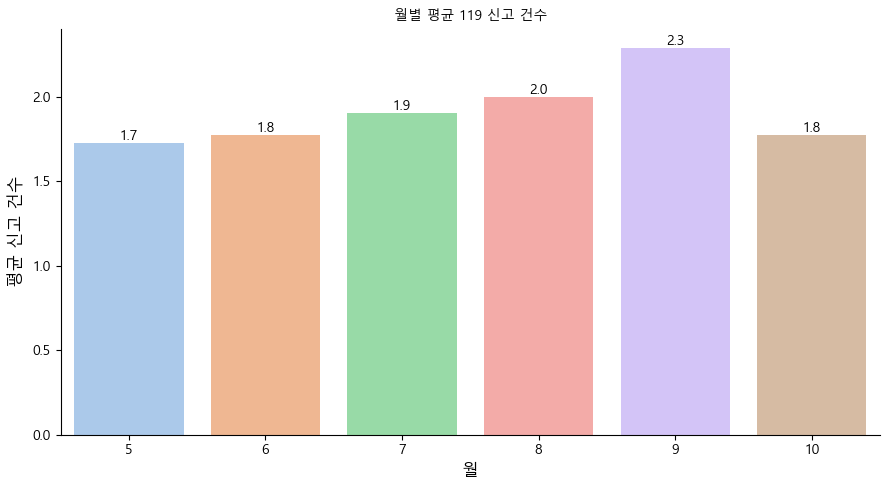

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager as fm

# 📌 폰트 경로 직접 설정 (Windows)
font_path = "C:/Windows/Fonts/malgun.ttf"  # 또는 NanumGothic.ttf, 원하는 ttf 경로
font_prop = fm.FontProperties(fname=font_path)

# 데이터 불러오기
df = pd.read_csv("C:/Users/THKIM/Desktop/3-1 프로젝트/데이터 마이닝 프로젝트/train/merged_119_combined.csv", encoding="utf-8")
df["call119_train.tm"] = pd.to_datetime(df["call119_train.tm"], errors="coerce", format="%Y%m%d")
df["month"] = df["call119_train.tm"].dt.month

# 집계
month_avg = df.groupby("month")["call119_train.call_count"].mean().reset_index()

# 시각화
plt.figure(figsize=(9, 5))
bar = sns.barplot(x="month", y="call119_train.call_count", data=month_avg, palette="pastel")

# 수치 라벨
for p in bar.patches:
    height = p.get_height()
    bar.annotate(f"{height:.1f}", (p.get_x() + p.get_width() / 2, height),
                 ha='center', va='bottom', fontsize=10, color='black', fontproperties=font_prop)

# 한글 텍스트에 직접 fontproperties 지정
plt.title("월별 평균 119 신고 건수", fontsize=14, fontweight="bold", fontproperties=font_prop)
plt.xlabel("월", fontsize=12, fontproperties=font_prop)
plt.ylabel("평균 신고 건수", fontsize=12, fontproperties=font_prop)
plt.xticks(fontsize=10, fontproperties=font_prop)
plt.yticks(fontsize=10, fontproperties=font_prop)

sns.despine()
plt.tight_layout()
plt.show()


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager as fm

# 📌 폰트 경로 (Windows 기준 Malgun Gothic)
font_path = "C:/Windows/Fonts/malgun.ttf"
font_prop = fm.FontProperties(fname=font_path)

# 시각화 스타일
sns.set_style("whitegrid")

# 데이터 로드
df = pd.read_csv("C:/Users/THKIM/Desktop/3-1 프로젝트/데이터 마이닝 프로젝트/train/merged_119_combined.csv", encoding="utf-8")
df["call119_train.tm"] = pd.to_datetime(df["call119_train.tm"], errors="coerce", format="%Y%m%d")


### 2. 강수 여부에 따른 신고 건수

C:\Users\THKIM\AppData\Local\Temp\ipykernel_6072\848458646.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar = sns.barplot(x="is_rainy", y="call119_train.call_count", data=grouped, palette="pastel")


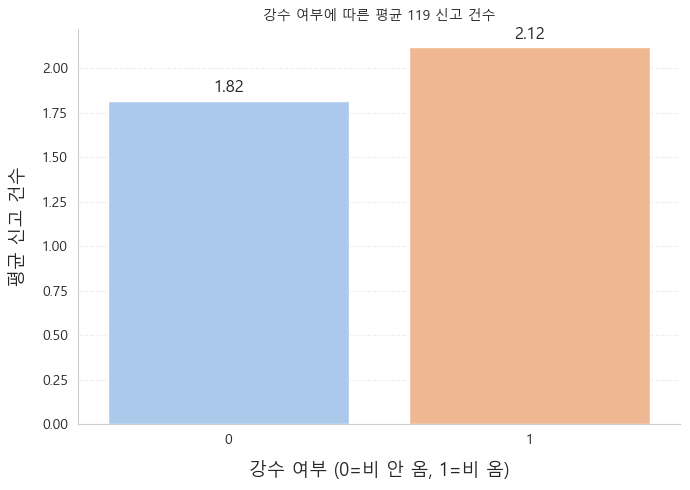

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager as fm

# 📌 폰트 설정
font_path = "C:/Windows/Fonts/malgun.ttf"
font_prop = fm.FontProperties(fname=font_path)

# 데이터 불러오기 및 처리
df = pd.read_csv("C:/Users/THKIM/Desktop/3-1 프로젝트/데이터 마이닝 프로젝트/train/merged_119_combined.csv", encoding="utf-8")
df["call119_train.tm"] = pd.to_datetime(df["call119_train.tm"], errors="coerce", format="%Y%m%d")
df["is_rainy"] = (df["call119_train.rn_day"] > 0).astype(int)

# 평균 집계
grouped = df.groupby("is_rainy")["call119_train.call_count"].mean().reset_index()

# 📊 시각화
plt.figure(figsize=(7, 5))
bar = sns.barplot(x="is_rainy", y="call119_train.call_count", data=grouped, palette="pastel")

# 텍스트 라벨 예쁘게 표시
for p in bar.patches:
    height = p.get_height()
    bar.annotate(f"{height:.2f}",
                 (p.get_x() + p.get_width()/2, height + 0.05),
                 ha='center', fontsize=12, fontweight='bold', fontproperties=font_prop)

# 제목 및 축 스타일링
plt.title("강수 여부에 따른 평균 119 신고 건수", fontsize=16, fontweight="bold", fontproperties=font_prop)
plt.xlabel("강수 여부 (0=비 안 옴, 1=비 옴)", fontsize=13, fontproperties=font_prop, labelpad=10)
plt.ylabel("평균 신고 건수", fontsize=13, fontproperties=font_prop, labelpad=10)
plt.xticks(fontsize=11, fontproperties=font_prop)
plt.yticks(fontsize=11, fontproperties=font_prop)

# 스타일 개선
sns.despine()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


### 3. 구별 신고 건수 Top 10

C:\Users\THKIM\AppData\Local\Temp\ipykernel_6072\1452052337.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bar = sns.barplot(y="call119_train.address_gu", x="call119_train.call_count", data=top_gu, palette="pastel")


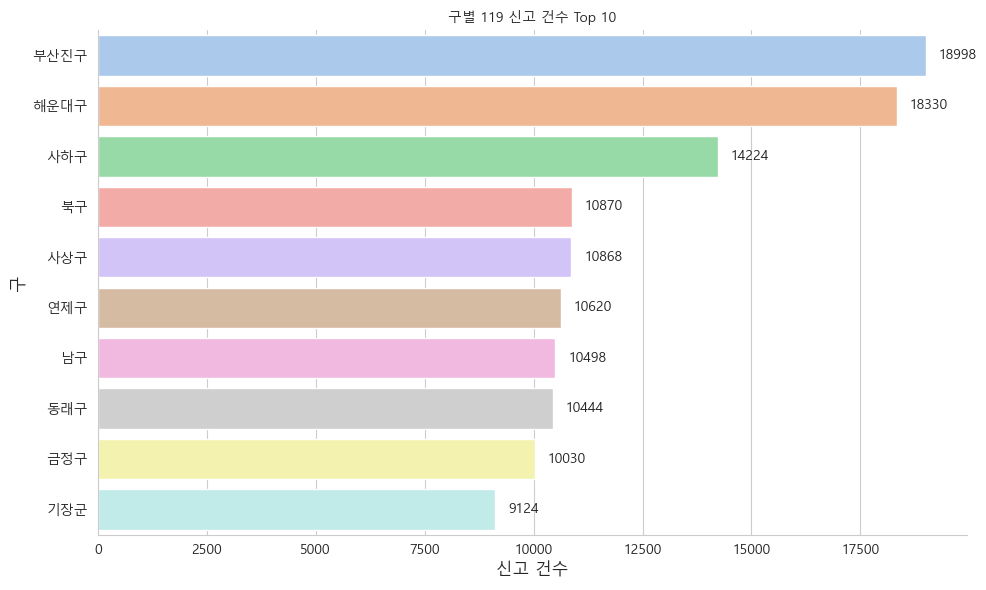

In [7]:
top_gu = df.groupby("call119_train.address_gu")["call119_train.call_count"].sum().reset_index()
top_gu = top_gu.sort_values(by="call119_train.call_count", ascending=False).head(10)

plt.figure(figsize=(10, 6))
bar = sns.barplot(y="call119_train.address_gu", x="call119_train.call_count", data=top_gu, palette="pastel")

# 수치 라벨
for p in bar.patches:
    width = p.get_width()
    plt.text(width + 300, p.get_y() + p.get_height()/2, f'{int(width)}',
             va='center', fontsize=10, fontproperties=font_prop)

plt.title("구별 119 신고 건수 Top 10", fontsize=14, fontweight="bold", fontproperties=font_prop)
plt.xlabel("신고 건수", fontsize=12, fontproperties=font_prop)
plt.ylabel("구", fontsize=12, fontproperties=font_prop)
plt.xticks(fontsize=10, fontproperties=font_prop)
plt.yticks(fontsize=10, fontproperties=font_prop)
sns.despine()
plt.tight_layout()
plt.show()


### 4. 기상 변수 vs 신고 건수 

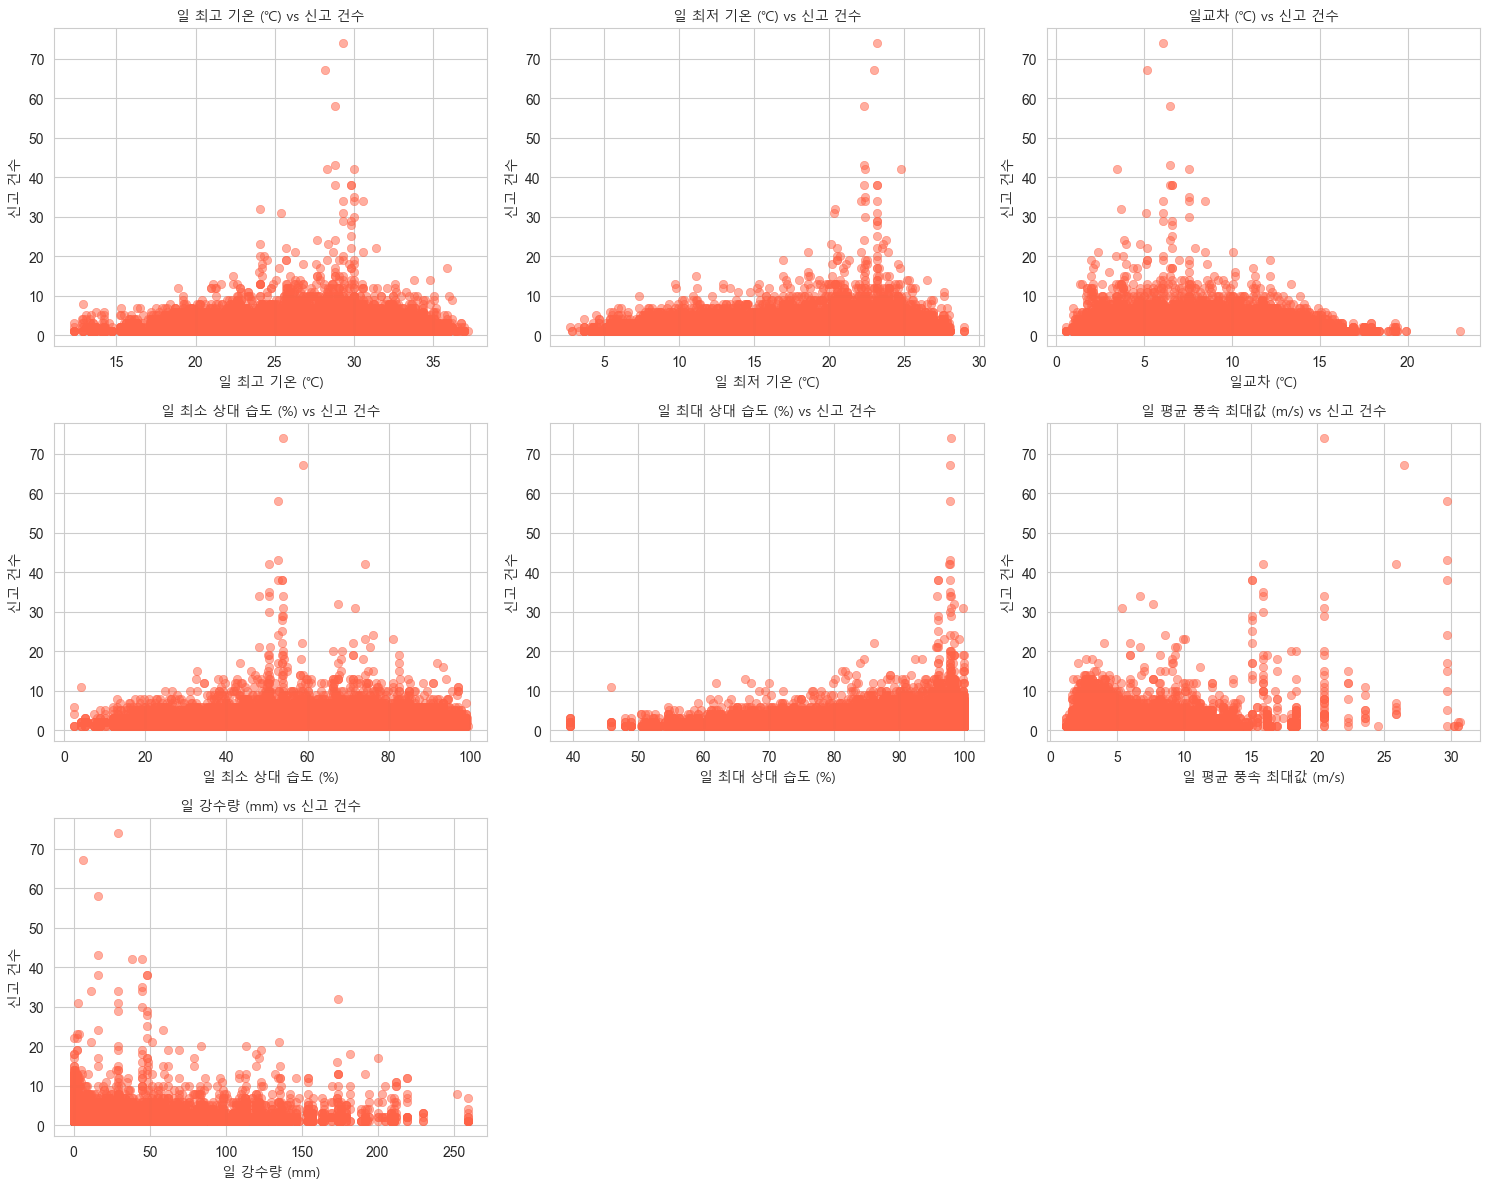

In [8]:
# 설명용 변수명 매핑
col_mapping = {
    "call119_train.ta_max": "일 최고 기온 (℃)",
    "call119_train.ta_min": "일 최저 기온 (℃)",
    "call119_train.ta_max_min": "일교차 (℃)",
    "call119_train.hm_min": "일 최소 상대 습도 (%)",
    "call119_train.hm_max": "일 최대 상대 습도 (%)",
    "call119_train.ws_max": "일 평균 풍속 최대값 (m/s)",
    "call119_train.rn_day": "일 강수량 (mm)"
}

# 이상치 제거
features = list(col_mapping.keys())
filtered_df = df.copy()
for col in features:
    filtered_df = filtered_df[filtered_df[col] > -99]

# 산점도 시각화
plt.figure(figsize=(15, 12))
for i, col in enumerate(features, 1):
    plt.subplot(3, 3, i)
    sns.scatterplot(x=filtered_df[col], y=filtered_df["call119_train.call_count"],
                    alpha=0.3, color="tomato", edgecolor=None)
    plt.xlabel(col_mapping[col], fontproperties=font_prop)
    plt.ylabel("신고 건수", fontproperties=font_prop)
    plt.title(f"{col_mapping[col]} vs 신고 건수", fontproperties=font_prop)

plt.tight_layout()
plt.show()


### 5. 시간 흐름에 따른 추세 확인

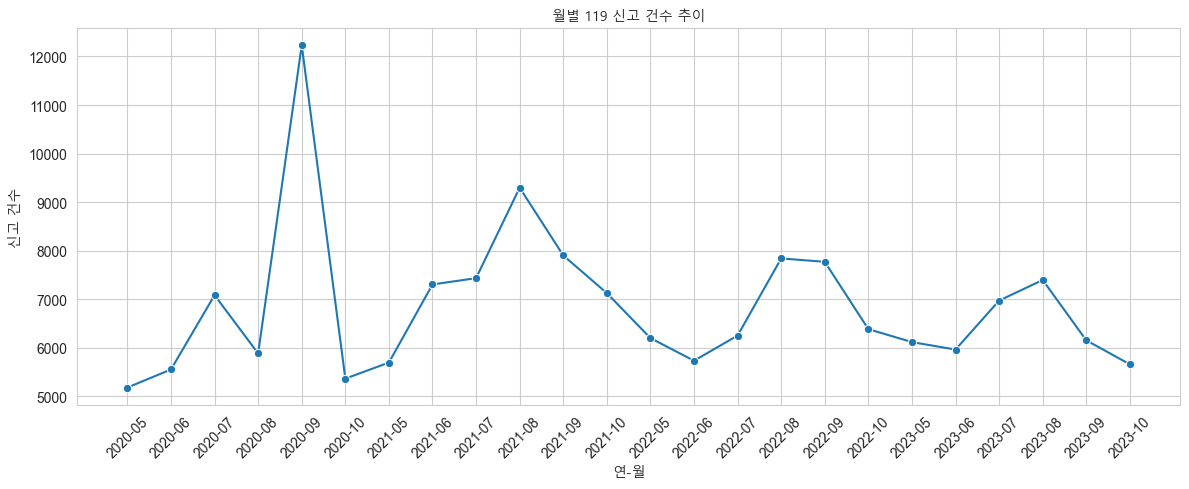

In [9]:
df["year_month"] = df["call119_train.tm"].dt.to_period("M")
monthly = df.groupby("year_month")["call119_train.call_count"].sum().reset_index()
monthly["year_month"] = monthly["year_month"].astype(str)

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly, x="year_month", y="call119_train.call_count", marker="o")
plt.xticks(rotation=45)
plt.title("월별 119 신고 건수 추이", fontproperties=font_prop)
plt.xlabel("연-월", fontproperties=font_prop)
plt.ylabel("신고 건수", fontproperties=font_prop)
plt.tight_layout()
plt.show()


### 신고 폭증일 (하루 50건 이상) 탐지 및 분석

In [10]:
df_peak = df[df['call119_train.call_count'] >= 50]
df_peak[['call119_train.tm', 'call119_train.call_count']].sort_values(by='call119_train.call_count', ascending=False)



,call119_train.tm,call119_train.call_count
49807,2020-09-03,115
6883,2020-09-03,115
49805,2020-09-03,105
6881,2020-09-03,105
6878,2020-09-03,89
49802,2020-09-03,89
49808,2020-09-03,87
6884,2020-09-03,87
6866,2020-09-03,74
49790,2020-09-03,74


### 폭증일의 기상요소 확인

In [11]:
cols = [
    'call119_train.tm', 'call119_train.call_count',
    'call119_train.ta_max', 'call119_train.ta_min', 'call119_train.ta_max_min',
    'call119_train.hm_min', 'call119_train.hm_max',
    'call119_train.ws_max', 'call119_train.ws_ins_max',
    'call119_train.rn_day'
]
df_peak[cols].sort_values(by='call119_train.call_count', ascending=False)


,call119_train.tm,call119_train.call_count,call119_train.ta_max,call119_train.ta_min,call119_train.ta_max_min,call119_train.hm_min,call119_train.hm_max,call119_train.ws_max,call119_train.ws_ins_max,call119_train.rn_day
49807,2020-09-03,115,30.2,22.5,7.7,49.9,96.2,13.1,21.3,-99.0
6883,2020-09-03,115,30.2,22.5,7.7,49.9,96.2,13.1,21.3,-99.0
49805,2020-09-03,105,30.2,22.5,7.7,49.9,96.2,13.1,21.3,-99.0
6881,2020-09-03,105,30.2,22.5,7.7,49.9,96.2,13.1,21.3,-99.0
6878,2020-09-03,89,30.2,22.5,7.7,49.9,96.2,13.1,21.3,-99.0
49802,2020-09-03,89,30.2,22.5,7.7,49.9,96.2,13.1,21.3,-99.0
49808,2020-09-03,87,30.2,22.5,7.7,49.9,96.2,13.1,21.3,-99.0
6884,2020-09-03,87,30.2,22.5,7.7,49.9,96.2,13.1,21.3,-99.0
6866,2020-09-03,74,29.3,23.2,6.1,54.0,98.0,20.5,35.7,28.9
49790,2020-09-03,74,29.3,23.2,6.1,54.0,98.0,20.5,35.7,28.9


#### is_typhoon 변수 생성 (풍속 25m/s, 강수량 50mm 이상)

In [12]:
import numpy as np

# -99 결측값 처리
df['call119_train.ws_ins_max'] = df['call119_train.ws_ins_max'].replace(-99, np.nan)
df['call119_train.rn_day'] = df['call119_train.rn_day'].replace(-99, np.nan)

# 태풍 조건 설정
wind_threshold = 25  # 단위: m/s
rain_threshold = 50  # 단위: mm

# 조건을 만족하면 1, 아니면 0
df['is_typhoon'] = np.where(
    (df['call119_train.ws_ins_max'] >= wind_threshold) &
    (df['call119_train.rn_day'] >= rain_threshold),
    1, 0
)

# 태풍 조건을 만족한 날만 보기
df[df['is_typhoon'] == 1][['call119_train.tm', 'call119_train.ws_ins_max', 'call119_train.rn_day']].drop_duplicates()


,call119_train.tm,call119_train.ws_ins_max,call119_train.rn_day
7160,2020-09-07,28.9,114.5
7167,2020-09-07,32.2,113.6
16904,2021-08-21,29.7,99.1
29062,2022-09-06,25.4,52.5
29067,2022-09-06,28.5,69.2
38239,2023-08-10,34.9,116.5
38241,2023-08-10,30.5,136.0
38257,2023-08-10,28.8,98.0
38263,2023-08-10,25.7,108.9


### 날짜/요일/주말 변수 생성 + 태풍 제외

In [13]:
# 날짜 형식 변환
df['call119_train.tm'] = pd.to_datetime(df['call119_train.tm'], errors='coerce')

# 요일, 주말 여부 파생
df['dayofweek'] = df['call119_train.tm'].dt.dayofweek  # 월:0 ~ 일:6
df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)

# 태풍 날 제외한 데이터셋 생성
df_clean = df[df['is_typhoon'] == 0]


In [14]:
# 다시 날짜 기반 파생변수 생성
df_clean['dayofweek'] = df_clean['call119_train.tm'].dt.dayofweek
df_clean['is_weekend'] = df_clean['dayofweek'].isin([5, 6]).astype(int)


C:\Users\THKIM\AppData\Local\Temp\ipykernel_6072\916879252.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['dayofweek'] = df_clean['call119_train.tm'].dt.dayofweek
C:\Users\THKIM\AppData\Local\Temp\ipykernel_6072\916879252.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['is_weekend'] = df_clean['dayofweek'].isin([5, 6]).astype(int)


In [15]:
# 요일별 평균 신고 건수
weekday_avg_clean = (
    df_clean.groupby("dayofweek")["call119_train.call_count"]
    .mean()
    .reset_index()
)

# 주말 vs 평일 평균 신고 건수
weekend_avg_clean = (
    df_clean.groupby("is_weekend")["call119_train.call_count"]
    .mean()
    .reset_index()
)


### 요일별 시계열 추이 그래프

C:\Users\THKIM\AppData\Local\Temp\ipykernel_6072\4173430327.py:48: UserWarning: Glyph 128198 (\N{TEAR-OFF CALENDAR}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
c:\Users\THKIM\anaconda3\envs\py11gpu\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128198 (\N{TEAR-OFF CALENDAR}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


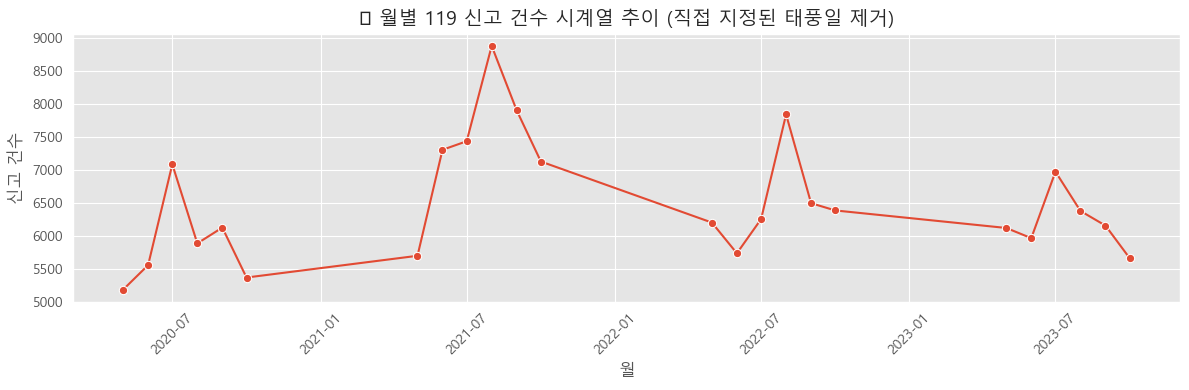

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

# 🎯 1. CSV 로드
df = pd.read_csv("C:/Users/THKIM/Desktop/3-1 프로젝트/데이터 마이닝 프로젝트/train/merged_119_combined.csv", encoding="UTF-8")

# 🎯 2. 날짜 변환 (정수형 yyyymmdd → datetime)
df['call119_train.tm'] = pd.to_datetime(df['call119_train.tm'], format="%Y%m%d", errors='coerce')

# ✅ 3. 제거 대상 날짜 리스트 지정
dates_to_exclude = [
    "2020-09-03", "2020-09-07", "2021-08-21",
    "2022-09-06", "2022-09-07", "2023-08-10"
]
dates_to_exclude = pd.to_datetime(dates_to_exclude)

# ✅ 4. 날짜 필터링 (위 날짜들 제거)
df_filtered = df[
    df['call119_train.tm'].notna() &
    (~df['call119_train.tm'].isin(dates_to_exclude))
]

# 🎯 5. 월별 신고 건수 집계
monthly_counts = (
    df_filtered
    .groupby(df_filtered['call119_train.tm'].dt.to_period("M"))["call119_train.call_count"]
    .sum()
    .reset_index()
)
monthly_counts['year_month'] = monthly_counts['call119_train.tm'].dt.to_timestamp()

# 🎯 6. 한글 + ggplot 스타일 시각화
plt.style.use('ggplot')
korean_fonts = [f.name for f in fm.fontManager.ttflist if 'Malgun' in f.name or 'AppleGothic' in f.name or 'Nanum' in f.name]
plt.rc('font', family=korean_fonts[0] if korean_fonts else 'sans-serif')
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(12, 4))
sns.lineplot(data=monthly_counts, x="year_month", y="call119_train.call_count", marker='o')
plt.title("📆 월별 119 신고 건수 시계열 추이 (직접 지정된 태풍일 제거)", fontsize=14)
plt.xlabel("월")
plt.ylabel("신고 건수")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


### 여름철 기상 요소 vs 신고 건수

In [ ]:
# 파생변수 포함된 최신 CSV 불러오기
df_extreme = pd.read_csv("C:/Users/THKIM/Desktop/3-1 프로젝트/데이터 마이닝 프로젝트/확정 데이터/119_filtered_with_extreme_weather_flags.csv", parse_dates=["call119_train.tm"])

# 관심 변수만 추출해 상관분석
corr_cols = [
    'call119_train.ta_max', 'call119_train.ta_min', 'call119_train.ta_max_min',
    'call119_train.hm_max', 'call119_train.hm_min',
    'call119_train.ws_max', 'call119_train.ws_ins_max',
    'call119_train.rn_day', 'call119_train.call_count',
    'is_heatwave', 'is_rainstorm', 'is_strongwind'
]

# 상관계수 히트맵 시각화
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
corr_matrix = df_extreme[corr_cols].dropna().corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("🔥 파생변수 포함 전체 상관관계 히트맵", fontsize=16)
plt.tight_layout()
plt.show()



### 날씨 파생변수 전처리

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, ttest_ind

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'AppleGothic'  # Mac인 경우
# plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows인 경우
plt.rcParams['axes.unicode_minus'] = False


### 1. 폭염

In [ ]:
heatwave = pd.read_csv('/Users/yeonsilyoo/Desktop/폭염 일수 .csv',encoding="utf-8")

      # 연도, 날짜, 관측값 포함
call119 = pd.read_csv("/Users/yeonsilyoo/Downloads/train_119.csv", encoding="euc-kr") 

In [ ]:
heatwave["날짜"] = heatwave["날짜"].astype(str).str.zfill(4)  # 817 → 0817
heatwave["full_date"] = pd.to_datetime(heatwave["연도"].astype(str) + heatwave["날짜"], format="%Y%m%d")
call119["tm"] = pd.to_datetime(call119["call119_train.tm"].astype(str), format="%Y%m%d")


In [ ]:
# 2. 날짜 포맷 변환
heatwave["날짜"] = heatwave["날짜"].astype(str).str.zfill(4)  # 817 → 0817
heatwave["full_date"] = pd.to_datetime(heatwave["연도"].astype(str) + heatwave["날짜"], format="%Y%m%d")
call119["tm"] = pd.to_datetime(call119["call119_train.tm"].astype(str), format="%Y%m%d")

# 3. 폭염일 여부 플래그 추가
heatwave_days = heatwave["full_date"].unique()
call119["is_heatwave_day"] = call119["tm"].isin(heatwave_days).astype(int)

# 4. 상관계수 분석
corr, p_corr = pearsonr(call119["call119_train.call_count"], call119["is_heatwave_day"])
print(f"📈 신고건수 vs 폭염일 상관계수: {corr:.3f} (p-value: {p_corr:.5f})")

# 📊 5. 박스플롯 시각화
plt.figure(figsize=(6, 5))
call119.boxplot(column="call119_train.call_count", by="is_heatwave_day", grid=False,
                patch_artist=True, boxprops=dict(facecolor="skyblue"))
plt.title("폭염일 여부에 따른 119 신고건수")
plt.suptitle("")
plt.xlabel("폭염일 여부 (0: 일반일, 1: 폭염일)")
plt.ylabel("신고건수")
plt.show()

# 📐 6. 평균 차이 t-test
group_0 = call119[call119["is_heatwave_day"] == 0]["call119_train.call_count"]
group_1 = call119[call119["is_heatwave_day"] == 1]["call119_train.call_count"]
t_stat, p_val = ttest_ind(group_0, group_1, equal_var=False)
print(f"📐 t-test: t={t_stat:.3f}, p-value={p_val:.5f}")


In [ ]:
import matplotlib.dates as mdates

# ✅ 연월 컬럼이 datetime 형식으로 되어 있어야 함
# df_merge["연월"] = pd.to_datetime(df_merge["연도"].astype(str) + "-" + df_merge["월"].astype(str))

fig, ax1 = plt.subplots(figsize=(14, 5))

# 🔴 폭염일수 (막대)
ax1.bar(df_merge["연월"], df_merge["폭염일수"], color="red", width=20)
ax1.set_ylabel("폭염일수 (일)", fontsize=12)
ax1.set_xlabel("연월", fontsize=12)
ax1.set_ylim(0, df_merge["폭염일수"].max() + 2)

# ⚫ 평균기온 (꺾은선)
ax2 = ax1.twinx()
ax2.plot(df_merge["연월"], df_merge["평균기온"], color="black", marker="o")
ax2.set_ylabel("평균 최고기온 (℃)", fontsize=12)
ax2.set_ylim(df_merge["평균기온"].min() - 1, df_merge["평균기온"].max() + 1)

# ✅ x축을 '연-월' 포맷으로 세분화
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))  # ← 핵심
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=1))  # ← 1달 간격 눈금
fig.autofmt_xdate(rotation=45)  # 자동 회전

# 📝 제목, 격자
plt.title("폭염일수 & 평균기온 (2020~2023)", fontsize=14)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


### ### 뇌전(번개)일수

In [ ]:
lightning = pd.read_csv('/Users/yeonsilyoo/Desktop/날씨공모저너ㅓ/평균 뇌전(번개) 일수.csv', encoding="utf-8")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# 1. 데이터 불러오기
lightning = pd.read_csv('/Users/yeonsilyoo/Desktop/날씨공모저너ㅓ/평균 뇌전(번개) 일수.csv', encoding="utf-8")
call119 = pd.read_csv('/Users/yeonsilyoo/Downloads/train_119.csv', encoding="euc-kr")


# 📐 2. 뇌전 데이터 전처리 (월별 형태로 melt)
df_lightning = lightning.melt(id_vars="연도",
                               value_vars=["1월","2월","3월","4월","5월","6월","7월","8월","9월","10월","11월","12월"],
                               var_name="월", value_name="뇌전일수")

# '1월' → 1 형식으로 정리
df_lightning["월"] = df_lightning["월"].str.replace("월", "").astype(int)

# '연도'에 텍스트(예: "평균")가 들어간 행 제거하고 숫자로 변환
df_lightning = df_lightning[df_lightning["연도"].str.isnumeric()]
df_lightning["연도"] = df_lightning["연도"].astype(int)

# 3. 신고데이터 전처리 (연월별 평균)
call119["tm"] = pd.to_datetime(call119["call119_train.tm"].astype(str), format="%Y%m%d")
call119["연도"] = call119["tm"].dt.year
call119["월"] = call119["tm"].dt.month

# 연도-월별 평균 신고건수
df_call = call119.groupby(["연도", "월"])["call119_train.call_count"].mean().reset_index()

# 4. 병합
df_merge = pd.merge(df_call, df_lightning, on=["연도", "월"], how="inner")

# 5. 상관계수 분석
corr, pval = pearsonr(df_merge["call119_train.call_count"], df_merge["뇌전일수"])
print(f"상관계수: {corr:.3f}, p-value: {pval:.5f}")

# 6. 시각화 (산점도)
plt.figure(figsize=(6,5))
plt.scatter(df_merge["뇌전일수"], df_merge["call119_train.call_count"], alpha=0.7)
plt.title("뇌전일수 vs 119 신고건수")
plt.xlabel("뇌전일수")
plt.ylabel("월 평균 신고건수")
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 🔹 melt된 뇌전일수 데이터 (기존 코드 결과)
# df_lightning = pd.DataFrame(columns=["연도", "월", "뇌전일수"])

# 🔹 연-월 조합 컬럼 추가
df_lightning["연월"] = pd.to_datetime(df_lightning["연도"].astype(str) + "-" + df_lightning["월"].astype(str))

# ✅ 시각화
plt.figure(figsize=(12, 5))
plt.bar(df_lightning["연월"], df_lightning["뇌전일수"], color="red", width=20)

plt.title("뇌전일수 월자료 (2020–2023)", fontsize=14)
plt.xlabel("월", fontsize=12)
plt.ylabel("일수", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis="y", linestyle="--", alpha=1)
plt.show()


### 안개

In [ ]:
# 📦 라이브러리
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# 1. 안개일수 데이터 불러오기
fog = pd.read_csv('/Users/yeonsilyoo/Desktop/날씨공모저너ㅓ/안개 일수 .csv', encoding='utf-8-sig')

# 2. 전처리: '평균' 행 제거 → 월별 형태로 melt
fog = fog[fog["연도"] != "평균"].copy()
fog["연도"] = fog["연도"].astype(int)

fog_melted = fog.melt(id_vars="연도",
                      value_vars=[f"{i}월" for i in range(1, 13)],
                      var_name="월", value_name="안개일수")

fog_melted["월"] = fog_melted["월"].str.replace("월", "").astype(int)
fog_melted["연월"] = pd.to_datetime(fog_melted["연도"].astype(str) + "-" + fog_melted["월"].astype(str))

# 3. 신고데이터 불러오기 및 전처리
call119 = pd.read_csv('/Users/yeonsilyoo/Downloads/train_119.csv', encoding="euc-kr")
call119["tm"] = pd.to_datetime(call119["call119_train.tm"].astype(str), format="%Y%m%d")
call119["연도"] = call119["tm"].dt.year
call119["월"] = call119["tm"].dt.month
call119["연월"] = pd.to_datetime(call119["연도"].astype(str) + "-" + call119["월"].astype(str))

# 연월별 평균 신고건수
df_call = call119.groupby("연월")["call119_train.call_count"].mean().reset_index()

# 4. 병합
df_merge = pd.merge(df_call, fog_melted[["연월", "안개일수"]], on="연월", how="inner")

# 5. 상관계수 분석
corr, pval = pearsonr(df_merge["call119_train.call_count"], df_merge["안개일수"])
print(f"상관계수: {corr:.3f}, p-value: {pval:.5f}")

# 6. 시각화 (산점도 + 회귀선)
import seaborn as sns
plt.rcParams["font.family"] = "AppleGothic"  # Mac용 / Windows는 'Malgun Gothic'
plt.rcParams["axes.unicode_minus"] = False

plt.figure(figsize=(8, 5))
sns.regplot(data=df_merge,
            x="안개일수", y="call119_train.call_count",
            scatter_kws={"alpha": 0.7}, line_kws={"color": "red"})
plt.title("안개일수 vs 119 신고건수", fontsize=14)
plt.xlabel("안개일수", fontsize=12)
plt.ylabel("월 평균 신고건수", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


### 폭풍

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# 1. 폭풍일수 평균 데이터 불러오기
storm = pd.read_csv('/Users/yeonsilyoo/Desktop/날씨공모저너ㅓ/폭풍일수 평균.csv', encoding='utf-8-sig')

# 2. '평균' 행 제거 및 정리
storm = storm[storm["연도"] != "평균"].copy()
storm["연도"] = storm["연도"].astype(int)

# 3. melt로 월별 정리
storm_melted = storm.melt(id_vars="연도", value_vars=[f"{i}월" for i in range(1, 13)],
                          var_name="월", value_name="폭풍일수")
storm_melted["월"] = storm_melted["월"].str.replace("월", "").astype(int)
storm_melted["연월"] = pd.to_datetime(storm_melted["연도"].astype(str) + "-" + storm_melted["월"].astype(str))

# 4. 119 신고데이터 불러오기
call119 = pd.read_csv('/Users/yeonsilyoo/Downloads/train_119.csv', encoding='euc-kr')
call119["tm"] = pd.to_datetime(call119["call119_train.tm"].astype(str), format="%Y%m%d")
call119["연월"] = call119["tm"].dt.to_period("M").dt.to_timestamp()
df_call = call119.groupby("연월")["call119_train.call_count"].mean().reset_index()

# 5. 병합
df_merge = pd.merge(df_call, storm_melted[["연월", "폭풍일수"]], on="연월", how="inner")

# 6. 상관계수 분석
corr, pval = pearsonr(df_merge["call119_train.call_count"], df_merge["폭풍일수"])
print(f"📈 상관계수: {corr:.3f}, p-value: {pval:.5f}")

# 7. 시각화 (산점도)
plt.figure(figsize=(10, 6))
sns.regplot(data=df_merge,
            x="폭풍일수", y="call119_train.call_count",
            scatter_kws={"s": 100, "alpha": 0.7, "color": "#FF5733"},   # 점: 진한 오렌지, 큼
            line_kws={"color": "black", "lw": 2})                       # 회귀선: 검정, 굵게

# 🔍 레이아웃
plt.title("폭풍일수 vs 119 신고건수", fontsize=18, fontweight="bold")
plt.xlabel("폭풍일수", fontsize=14)
plt.ylabel("월 평균 신고건수", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.4)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

### 우박

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# 1. 우박일수 데이터 불러오기
hail = pd.read_csv('/Users/yeonsilyoo/Desktop/날씨공모저너ㅓ/우박일수.csv', encoding='utf-8-sig')

# 2. '평균' 행 제거
hail = hail[hail['연도'] != '평균'].copy()
hail['연도'] = hail['연도'].astype(int)

# 3. 월별로 melt
hail_melted = hail.melt(id_vars='연도', 
                        value_vars=[f"{i}월" for i in range(1, 13)],
                        var_name='월', value_name='우박일수')
hail_melted['월'] = hail_melted['월'].str.replace('월', '').astype(int)
hail_melted['연월'] = pd.to_datetime(hail_melted['연도'].astype(str) + '-' + hail_melted['월'].astype(str))

# 4. 119 신고건수 데이터 불러오기
call119 = pd.read_csv('/Users/yeonsilyoo/Downloads/train_119.csv', encoding='euc-kr')
call119['tm'] = pd.to_datetime(call119['call119_train.tm'].astype(str), format='%Y%m%d')
call119['연월'] = call119['tm'].dt.to_period('M').dt.to_timestamp()
call_monthly = call119.groupby('연월')['call119_train.call_count'].mean().reset_index()

# 5. 병합
df_merge = pd.merge(call_monthly, hail_melted[['연월', '우박일수']], on='연월', how='inner')

# 6. 상관계수 분석
corr, pval = pearsonr(df_merge['call119_train.call_count'], df_merge['우박일수'])
print(f"📈 상관계수: {corr:.3f}, p-value: {pval:.5f}")

# 7. 시각화 (회귀선 포함 산점도)
plt.figure(figsize=(8, 5))
sns.regplot(data=df_merge, x='우박일수', y='call119_train.call_count',
            scatter_kws={'s': 90, 'alpha': 0.8, 'color': '#2a9d8f'},
            line_kws={'color': 'black', 'linewidth': 2})
plt.title('우박일수 vs 119 신고건수', fontsize=16, fontweight='bold')
plt.xlabel('우박일수', fontsize=13)
plt.ylabel('월 평균 신고건수', fontsize=13)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### 바람

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# 1. 바람 데이터 불러오기
wind = pd.read_csv('/Users/yeonsilyoo/Desktop/날씨공모저너ㅓ/바람_20250522153310.csv', encoding='cp949')
wind.columns = wind.columns.str.strip()
wind["일시"] = wind["일시"].str.strip()

# 2. 연월 포맷 정리
month_map = {
    "Jan": "01", "Feb": "02", "Mar": "03", "Apr": "04", "May": "05", "Jun": "06",
    "Jul": "07", "Aug": "08", "Sep": "09", "Oct": "10", "Nov": "11", "Dec": "12"
}
extracted = wind["일시"].str.extract(r"(\d+)\.(\w+)")
wind["연도"] = extracted[0].apply(lambda x: f"20{x}")
wind["월"] = extracted[1].map(month_map)
wind["연월"] = pd.to_datetime(wind["연도"] + "-" + wind["월"])

# 3. 바람 데이터 정리
wind_subset = wind[["연월", "최대순간풍속(m/s)"]].copy()
wind_subset.columns = ["연월", "최대순간풍속"]

# 4. 119 신고데이터 불러오기 및 월별 평균
call119 = pd.read_csv('/Users/yeonsilyoo/Downloads/train_119.csv', encoding='euc-kr')
call119["tm"] = pd.to_datetime(call119["call119_train.tm"].astype(str), format="%Y%m%d")
call119["연월"] = call119["tm"].dt.to_period("M").dt.to_timestamp()
df_call = call119.groupby("연월")["call119_train.call_count"].mean().reset_index()

# 5. 병합
df_merge = pd.merge(df_call, wind_subset, on="연월", how="inner")

# 6. 상관계수 분석
corr, pval = pearsonr(df_merge["call119_train.call_count"], df_merge["최대순간풍속"])
print(f"📈 상관계수: {corr:.3f}, p-value: {pval:.5f}")

# 7. 시각화 (산점도 + 회귀선)
plt.figure(figsize=(10, 6))
sns.regplot(data=df_merge,
            x="최대순간풍속", y="call119_train.call_count",
            scatter_kws={"s": 100, "alpha": 0.7, "color": "#FF5733"},
            line_kws={"color": "black", "lw": 2})

plt.title("최대순간풍속 vs 119 신고건수", fontsize=18, fontweight="bold")
plt.xlabel("최대순간풍속 (m/s)", fontsize=14)
plt.ylabel("월 평균 신고건수", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.4)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()


### 강수량

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# 1. 강수량 데이터 불러오기
rain = pd.read_csv('/Users/yeonsilyoo/Desktop/날씨공모저너ㅓ/강수량_20250522153050.csv',encoding='euc-kr')
rain.columns = rain.columns.str.strip()
rain["일시"] = rain["일시"].str.strip()

# 2. 연월 포맷 정리
month_map = {
    "Jan": "01", "Feb": "02", "Mar": "03", "Apr": "04", "May": "05", "Jun": "06",
    "Jul": "07", "Aug": "08", "Sep": "09", "Oct": "10", "Nov": "11", "Dec": "12"
}
extracted = rain["일시"].str.extract(r"(\d+)\.(\w+)")
rain["연도"] = extracted[0].apply(lambda x: f"20{x}")
rain["월"] = extracted[1].map(month_map)
rain["연월"] = pd.to_datetime(rain["연도"] + "-" + rain["월"])

# 3. 강수량 데이터 정리
rain_subset = rain[["연월", "강수량(mm)"]].copy()
rain_subset.columns = ["연월", "강수량"]
rain_subset = rain_subset.dropna()

# 4. 119 신고데이터 불러오기 및 월별 평균
call119 = pd.read_csv('/Users/yeonsilyoo/Downloads/train_119.csv',encoding="euc-kr")
call119["tm"] = pd.to_datetime(call119["call119_train.tm"].astype(str), format="%Y%m%d")
call119["연월"] = call119["tm"].dt.to_period("M").dt.to_timestamp()
df_call = call119.groupby("연월")["call119_train.call_count"].mean().reset_index()

# 5. 병합
df_merge = pd.merge(df_call, rain_subset, on="연월", how="inner")

# 6. 상관계수 분석
corr, pval = pearsonr(df_merge["call119_train.call_count"], df_merge["강수량"])
print(f"📈 상관계수: {corr:.3f}, p-value: {pval:.5f}")

# 7. 시각화 (산점도 + 회귀선)
plt.figure(figsize=(10, 6))
sns.regplot(data=df_merge,
            x="강수량", y="call119_train.call_count",
            scatter_kws={"s": 100, "alpha": 0.7, "color": "#1f77b4"},
            line_kws={"color": "black", "lw": 2})

plt.title("강수량 vs 119 신고건수", fontsize=18, fontweight="bold")
plt.xlabel("강수량 (mm)", fontsize=14)
plt.ylabel("월 평균 신고건수", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.4)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()


### 기온

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# 1. 평균기온 데이터 불러오기
temp = pd.read_csv('/Users/yeonsilyoo/Desktop/날씨공모저너ㅓ/기온_20250522153012.csv', encoding='cp949')
temp.columns = temp.columns.str.strip()
temp["일시"] = temp["일시"].str.strip()

# 2. 연월 파싱
month_map = {
    "Jan": "01", "Feb": "02", "Mar": "03", "Apr": "04", "May": "05", "Jun": "06",
    "Jul": "07", "Aug": "08", "Sep": "09", "Oct": "10", "Nov": "11", "Dec": "12"
}
extracted = temp["일시"].str.extract(r"(\d+)\.(\w+)")
temp["연도"] = extracted[0].apply(lambda x: f"20{x}")
temp["월"] = extracted[1].map(month_map)
temp["연월"] = pd.to_datetime(temp["연도"] + "-" + temp["월"])

# 3. 기온 데이터 정리
temp_subset = temp[["연월", "평균기온(℃)"]].copy()
temp_subset.columns = ["연월", "평균기온"]
temp_subset = temp_subset.dropna()

# 4. 119 신고 데이터 불러오기 및 월평균 계산
call119 = pd.read_csv('/Users/yeonsilyoo/Downloads/train_119.csv', encoding='euc-kr')
call119["tm"] = pd.to_datetime(call119["call119_train.tm"].astype(str), format="%Y%m%d")
call119["연월"] = call119["tm"].dt.to_period("M").dt.to_timestamp()
df_call = call119.groupby("연월")["call119_train.call_count"].mean().reset_index()

# 5. 병합
df_merge = pd.merge(df_call, temp_subset, on="연월", how="inner")

# 6. 상관계수 분석
corr, pval = pearsonr(df_merge["call119_train.call_count"], df_merge["평균기온"])
print(f"📈 상관계수: {corr:.3f}, p-value: {pval:.5f}")

# 7. 시각화
plt.figure(figsize=(10, 6))
sns.regplot(data=df_merge,
            x="평균기온", y="call119_train.call_count",
            scatter_kws={"s": 100, "alpha": 0.7, "color": "#e67e22"},
            line_kws={"color": "black", "lw": 2})

plt.title("평균기온 vs 119 신고건수", fontsize=18, fontweight="bold")
plt.xlabel("평균기온 (°C)", fontsize=14)
plt.ylabel("월 평균 신고건수", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.4)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()


### 인구데이터 전처리 

#### 부산광역시 전체 인구

In [ ]:
import pandas as pd

# [1] 데이터 로드
df = pd.read_csv("C:/Users/THKIM/Desktop/3-1 프로젝트/데이터 마이닝 프로젝트/예비 데이터/부산광역시_전체_세대_및_인구개황_20250516143405.csv", encoding="utf-8")
df = df.iloc[1:].reset_index(drop=True)
df.rename(columns={df.columns[0]: "구군"}, inplace=True)

# [2] 부산광역시 집계 행 제거
df = df[df["구군"] != "부산광역시"].copy()

# [3] 2024년 데이터 제외
df = df.drop(columns=[col for col in df.columns if col.startswith("2024.")])

# [4] 지표 매핑
indicator_map = {
    ".1": "세대수",
    ".2": "인구수",
    ".6": "면적",
    ".7": "인구밀도"
}

# [5] 사용할 컬럼 필터링
selected_cols = [col for col in df.columns if any(col.endswith(suffix) for suffix in indicator_map)]
df_filtered = df[["구군"] + selected_cols].copy()

# [6] long-form 변환
df_long = df_filtered.melt(id_vars="구군", var_name="연월지표", value_name="값")
df_long["연월"] = df_long["연월지표"].str.extract(r"^(\d{4}\.\d{2})")
df_long["지표"] = df_long["연월지표"].str.extract(r"(\.\d)$").replace(indicator_map)
df_long["값"] = pd.to_numeric(df_long["값"], errors="coerce")

# [7] 피벗
df_tidy = df_long.pivot(index=["구군", "연월"], columns="지표", values="값").reset_index()
df_tidy = df_tidy[["구군", "연월", "세대수", "인구수", "인구밀도", "면적"]]

# [8] CSV로 저장
output_path = "C:/Users/THKIM/Desktop/3-1 프로젝트/데이터 마이닝 프로젝트/예비 데이터/인구 데이터/부산_구별_월별_인구지표_2020_2023.csv"
df_tidy.to_csv(output_path, index=False)

output_path


In [ ]:
import pandas as pd

# 파일 불러오기 및 첫 행 제거
df = pd.read_csv("C:/Users/THKIM/Desktop/3-1 프로젝트/데이터 마이닝 프로젝트/예비 데이터/부산광역시_전체_세대_및_인구개황_20250516143405.csv", encoding="utf-8")
df

In [ ]:
import pandas as pd
data_ratio=pd.read_csv("C:/Users/THKIM/Desktop/3-1 프로젝트/데이터 마이닝 프로젝트/확정 데이터/부산광역시_인구_추가변수.csv")
data_ratio

### 학습 데이터 merge

In [ ]:
# call119_train.address_gu 기준으로 원핫 인코딩
gu_dummies = pd.get_dummies(df_119['call119_train.address_gu'], prefix='gu')

# 기존 df_119에 병합
df_119 = pd.concat([df_119, gu_dummies], axis=1)


In [ ]:
df_e=pd.read_csv('부산광역시_인구_추가변수.csv', encoding='utf-8')

In [ ]:
# 1. df_e를 long 형태로 변환 (gu_열 → call119_train.address_gu로 매칭할 수 있게)
gu_columns = [col for col in df_e.columns if col.startswith('gu_')]

df_e_long = df_e.melt(
    id_vars=['연도', '세대수', '인구수', 'population_density', '면적',
             'senior_ratio', 'youth_ratio', 'foreign_ratio', 'urban_zone'],
    value_vars=gu_columns,
    var_name='구', value_name='value'
)

# 2. value==1인 행만 추출
df_e_long = df_e_long[df_e_long['value'] == 1].drop(columns='value')

# 3. 구 이름 정제
df_e_long['call119_train.address_gu'] = df_e_long['구'].str.replace('gu_', '', regex=False)

# 4. 컬럼명 통일
df_e_long = df_e_long.rename(columns={'연도': 'year'})

# 5. 병합 수행
df_119 = df_119.merge(df_e_long.drop(columns='구'), on=['year', 'call119_train.address_gu'], how='left')


In [ ]:
df_f=pd.read_csv('기상데이터_최종.csv',encoding='utf-8')

In [ ]:
# 일시 열을 문자열로 변환 후 '.' 기준으로 분리
df_f[['year', 'month', 'day']] = df_f['일시'].astype(str).str.split('.', expand=True)

# 정수형으로 변환
df_f[['year', 'month', 'day']] = df_f[['year', 'month', 'day']].astype(int)

# 필요한 열만 사용하여 병합
df_119 = df_119.merge(
    df_f.drop(columns=['일시']),  # 일시는 이미 year/month/day로 분해되어 있으므로 생략
    on=['year', 'month', 'day'],
    how='left'
)


In [ ]:
df_119

### 파생변수 상관관계 분석

call119_train.call_count    1.000000
폭풍(m/s)                     0.474585
강수량(mm)                     0.111914
call119_train.ws_ins_max    0.096720
인구수                         0.094328
call119_train.stn           0.090687
call119_train.rn_day        0.089353
세대수                         0.086057
population_density          0.081036
fire_dispatch_count         0.074963
call119_train.ws_max        0.067500
최저기온(℃)                     0.059050
불쾌지수                        0.056452
ta_avg                      0.055139
평균기온(℃)                     0.055139
call119_train.ta_min        0.039752
최고기온(℃)                     0.039220
hm_avg                      0.037844
call119_train.ta_max        0.027028
열대야기온(℃)                    0.021050
youth_ratio                 0.010065
폭염기온(℃)                     0.009258
습한날                         0.005648
call119_train.hm_min       -0.005863
뇌전횟수                       -0.006715
call119_train.ta_max_min   -0.008472
뇌전유무                       -0.009238
c

C:\Users\THKIM\AppData\Local\Temp\ipykernel_6072\1369455673.py:31: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
c:\Users\THKIM\anaconda3\envs\py11gpu\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


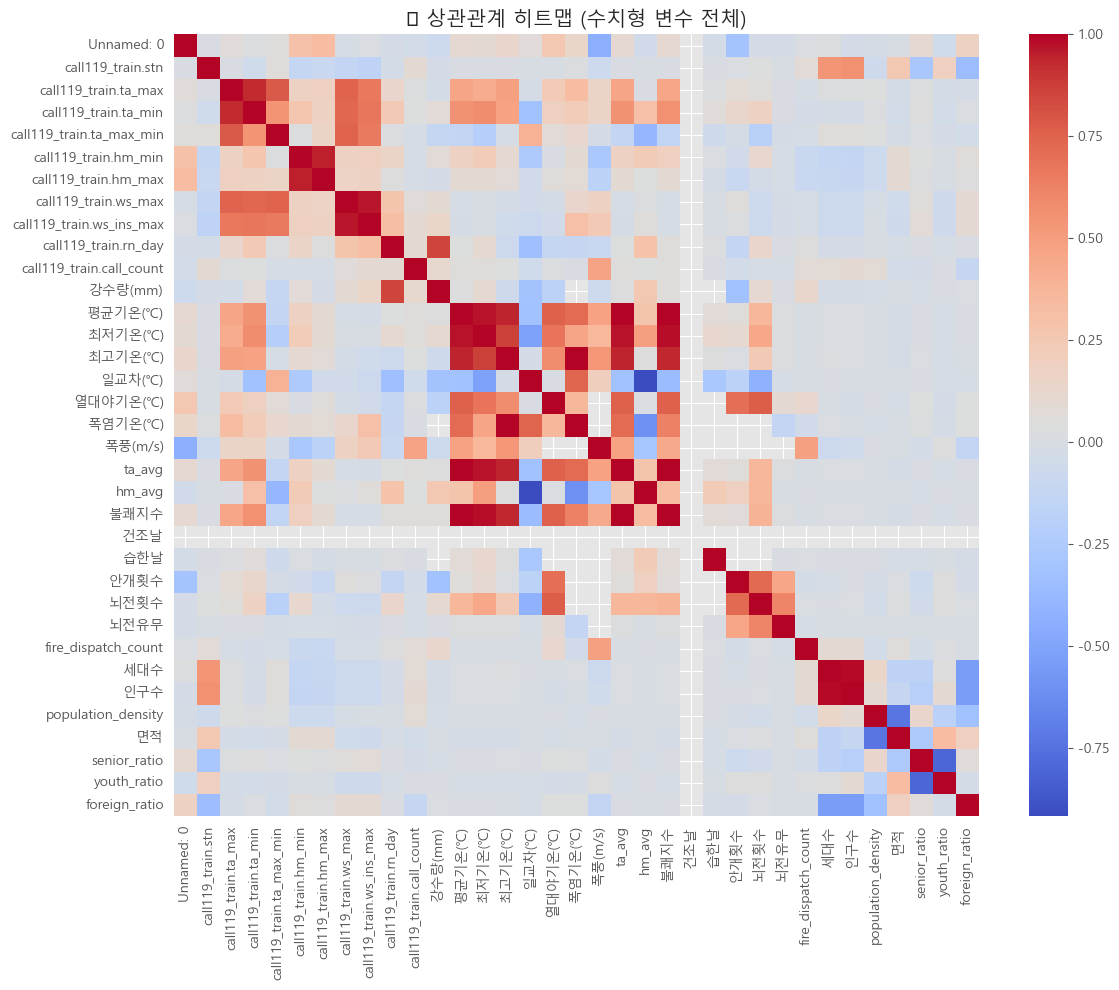

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. CSV 불러오기
df = pd.read_csv("C:/Users/THKIM/Desktop/3-1 프로젝트/데이터 마이닝 프로젝트/확정 데이터/df_1.csv")  # 파일 이름에 맞게 수정 필요

# 2. 날짜 컬럼 처리
df['call119_train.tm'] = pd.to_datetime(df['call119_train.tm'], format="%Y%m%d")

# 3. 2020~2023년 5~10월 필터링
df_filtered = df[
    (df['call119_train.tm'].dt.year >= 2020) &
    (df['call119_train.tm'].dt.year <= 2023) &
    (df['call119_train.tm'].dt.month >= 5) &
    (df['call119_train.tm'].dt.month <= 10)
]

# 4. 수치형 변수만 추출하여 상관계수 계산
numeric_df = df_filtered.select_dtypes(include='number')
corr_matrix = numeric_df.corr(numeric_only=True)

# 5. 신고 건수 기준으로 상관계수 정렬
call_corr = corr_matrix['call119_train.call_count'].sort_values(ascending=False)
print(call_corr)

# 6. 히트맵 시각화
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, fmt=".2f")
plt.title("📊 상관관계 히트맵 (수치형 변수 전체)")
plt.tight_layout()
plt.show()


In [19]:
# 사용 가능한 모든 컬럼 중 타깃과 식별자 제외
target_col = 'call119_train.call_count'
exclude_cols = ['Unnamed: 0', 'call119_train.tm', target_col]
feature_cols = [col for col in df.columns if col not in exclude_cols]

X = df[feature_cols]
y = np.log1p(df[target_col])  # log1p 변환

# 학습/검증 분할
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)


In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error
import shap

# ✅ [1] 데이터 로드
df = pd.read_csv("C:/Users/THKIM/Desktop/3-1 프로젝트/데이터 마이닝 프로젝트/확정 데이터/df_1.csv")  # 파일 경로 알맞게 수정

# ✅ [2] 타겟 정의 및 불필요한 컬럼 제거
target_col = 'call119_train.call_count'
drop_cols = ['Unnamed: 0', 'call119_train.tm', target_col, '날짜']  # 날짜 제거 중요

# ✅ [3] 날짜 파생변수 생성 (예: month, weekday 등, 필요 시 확장 가능)
df['날짜'] = pd.to_datetime(df['날짜'], errors='coerce')
df['month'] = df['날짜'].dt.month
df['weekday'] = df['날짜'].dt.weekday
df['is_weekend'] = df['weekday'].isin([5, 6]).astype(int)

# ✅ [4] 범주형 변수 원-핫 인코딩 (drop_first로 다중공선성 방지)
df = pd.get_dummies(df, drop_first=True)

# ✅ [5] Feature / Target 분리
feature_cols = [col for col in df.columns if col not in drop_cols]
X = df[feature_cols]
y = np.log1p(df[target_col])  # 로그 변환

# ✅ [6] 학습/검증 분할
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ✅ [7] 모델 정의 + 하이퍼파라미터 튜닝 설정
model = XGBRegressor(objective='reg:squarederror', random_state=42)
param_grid = {
    'learning_rate': [0.05, 0.1],
    'max_depth': [4, 6],
    'n_estimators': [100, 200]
}
grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

# ✅ [8] 학습 수행
grid.fit(X_train, y_train)
best_model = grid.best_estimator_

# ✅ [9] 평가
pred_val_log = best_model.predict(X_val)
pred_val = np.expm1(pred_val_log)  # 역로그 변환
true_val = np.expm1(y_val)

rmse = mean_squared_error(true_val, pred_val, squared=False)
print("✅ 최적 하이퍼파라미터:", grid.best_params_)
print(f"📉 검증 RMSE: {rmse:.4f}")

# ✅ [10] SHAP 분석 준비
explainer = shap.Explainer(best_model)
shap_values = explainer(X_val)

# 예시: 중요도 시각화
shap.plots.bar(shap_values, max_display=15)


In [ ]:
import shap

explainer = shap.Explainer(best_model)
shap_values = explainer(X_train)

# 요약 플롯
shap.summary_plot(shap_values, X_train)


### 모델 학습 (ensemble model)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor
import optuna
import warnings
warnings.filterwarnings("ignore")

# 🚀 [1] 데이터 로딩
df = pd.read_csv("C:/Users/THKIM/Desktop/3-1 프로젝트/데이터 마이닝 프로젝트/확정 데이터/df_1.csv", parse_dates=['날짜'])

# 🚀 [2] 행정동 기준 집계
df_dong = df.groupby(['call119_train.sub_address', '날짜']).agg({
    'call119_train.call_count': 'sum',
    '강수량(mm)': 'mean',
    '최저기온(℃)': 'mean',
    '최고기온(℃)': 'mean',
    '불쾌지수': 'mean',
    'hm_avg': 'mean',
    '면적': 'first',
    '인구수': 'first',
    '세대수': 'first',
    'foreign_ratio': 'first',
    'population_density': 'first'
}).reset_index()

# 🚀 [3] 시계열 변수 생성
df_dong = df_dong.sort_values(['call119_train.sub_address', '날짜'])
df_dong['call_count_lag2'] = df_dong.groupby('call119_train.sub_address')['call119_train.call_count'].shift(2)
df_dong['call_count_roll7'] = df_dong.groupby('call119_train.sub_address')['call119_train.call_count'].rolling(7).mean().reset_index(0, drop=True)
df_dong['call_count_diff'] = df_dong.groupby('call119_train.sub_address')['call119_train.call_count'].diff(1)
df_dong['call_count_3day_mean'] = (
    df_dong.groupby('call119_train.sub_address')['call119_train.call_count']
    .shift(1).rolling(3).mean().reset_index(0, drop=True)
)

# 🚀 [4] 보간
df_dong.set_index('날짜', inplace=True)
for col in ['강수량(mm)', '최저기온(℃)', '불쾌지수', 'hm_avg']:
    df_dong[col] = df_dong[col].interpolate(method='time')
    df_dong[col] = df_dong[col].fillna(df_dong[col].median())
df_dong.reset_index(inplace=True)

# 🚀 [5] 클러스터링
region_stats = df_dong.groupby('call119_train.sub_address')[['call119_train.call_count', 'population_density', '면적']].mean()
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
region_stats['지역클러스터'] = kmeans.fit_predict(region_stats)
df_dong['지역클러스터'] = df_dong['call119_train.sub_address'].map(region_stats['지역클러스터'])

# 🚀 [6] Split
df_dong = df_dong.dropna()
train_df = df_dong[(df_dong['날짜'] >= '2020-05-01') & (df_dong['날짜'] <= '2022-10-31')]
valid_df = df_dong[(df_dong['날짜'] >= '2023-05-01') & (df_dong['날짜'] <= '2023-10-31')]

features_final = [
    '면적', '인구수', '세대수', 'foreign_ratio', 'population_density',
    '강수량(mm)', '최저기온(℃)', '최고기온(℃)', '불쾌지수', 'hm_avg',
    'call_count_lag2', 'call_count_roll7',
    'call_count_diff', 'call_count_3day_mean', '지역클러스터'
]

X_train = train_df[features_final]
y_train = train_df['call119_train.call_count']
X_valid = valid_df[features_final]
y_valid = valid_df['call119_train.call_count']

# 🚀 [6-1] 가중치 생성: 고신고일에 더 높은 가중치 부여
# 기준: 신고건수가 75% 이상이면 가중치 2, 그 외는 1
q75 = y_train.quantile(0.75)
sample_weight = np.where(y_train >= q75, 2, 1)

# 🚀 [7] Optuna 튜닝 함수 (GPU 옵션 반영 + 가중치 적용)
def tune_model(model_type='xgb'):
    def objective(trial):
        if model_type == 'xgb':
            params = {
                'n_estimators': trial.suggest_int('n_estimators', 100, 300),
                'max_depth': trial.suggest_int('max_depth', 3, 10),
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
                'subsample': trial.suggest_float('subsample', 0.6, 1.0),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
                'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 5.0),
                'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 5.0),
                'tree_method': 'gpu_hist',
                'random_state': 42
            }
            model = XGBRegressor(**params)

        elif model_type == 'rf':
            params = {
                'n_estimators': trial.suggest_int('n_estimators', 100, 300),
                'max_depth': trial.suggest_int('max_depth', 5, 15),
                'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
                'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
                'random_state': 42,
                'n_jobs': -1
            }
            model = RandomForestRegressor(**params)

        elif model_type == 'cat':
            params = {
                'iterations': trial.suggest_int('iterations', 100, 300),
                'depth': trial.suggest_int('depth', 4, 10),
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
                'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 5.0),
                'task_type': 'GPU',
                'devices': '0',
                'random_seed': 42,
                'verbose': 0
            }
            model = CatBoostRegressor(**params)

        tscv = TimeSeriesSplit(n_splits=5)
        rmse_scores = []
        for train_idx, val_idx in tscv.split(X_train):
            X_t, X_v = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_t, y_v = y_train.iloc[train_idx], y_train.iloc[val_idx]
            w_t = sample_weight[train_idx] if model_type in ['xgb', 'cat'] else None
            if model_type in ['xgb', 'cat']:
                model.fit(X_t, y_t, sample_weight=w_t)
            else:
                model.fit(X_t, y_t)  # RF는 내부 가중치 지원 어려움
            preds = model.predict(X_v)
            rmse_scores.append(np.sqrt(mean_squared_error(y_v, preds)))
        return np.mean(rmse_scores)

    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=1000)
    return study.best_trial.params

# 🚀 [8] 모델 튜닝 및 학습 (가중치 적용)
best_xgb = tune_model('xgb')
best_rf = tune_model('rf')
best_cat = tune_model('cat')

model_xgb = XGBRegressor(**best_xgb)
model_rf = RandomForestRegressor(**best_rf)
model_cat = CatBoostRegressor(**best_cat)

model_xgb.fit(X_train, y_train, sample_weight=sample_weight)
model_rf.fit(X_train, y_train)  # RF는 sample_weight 활용 어려움
model_cat.fit(X_train, y_train, sample_weight=sample_weight)

# 🚀 [9] 예측 + 앙상블
pred_xgb = model_xgb.predict(X_valid)
pred_rf = model_rf.predict(X_valid)
pred_cat = model_cat.predict(X_valid)
ensemble_pred = (pred_xgb + pred_rf + pred_cat) / 3

# 🚀 [10] 평가
rmse = np.sqrt(mean_squared_error(y_valid, ensemble_pred))
r2 = r2_score(y_valid, ensemble_pred)

print("\n📊 [Ensemble RMSE]:", rmse)
print("📊 [Ensemble R²]:", r2)


[I 2025-06-26 04:53:35,546] A new study created in memory with name: no-name-8b284ec0-81b2-46dc-b1b7-49730d1a4115
[I 2025-06-26 04:53:39,391] Trial 0 finished with value: 2.9072439265959593 and parameters: {'n_estimators': 208, 'max_depth': 8, 'learning_rate': 0.01170491232591403, 'subsample': 0.6340699067735307, 'colsample_bytree': 0.6476010839591554, 'reg_alpha': 3.0752268125779376, 'reg_lambda': 4.705457460567618}. Best is trial 0 with value: 2.9072439265959593.
[I 2025-06-26 04:53:44,790] Trial 1 finished with value: 1.8927147291990096 and parameters: {'n_estimators': 262, 'max_depth': 9, 'learning_rate': 0.02060101435851383, 'subsample': 0.6164253895293673, 'colsample_bytree': 0.8709404970583872, 'reg_alpha': 4.556443439812426, 'reg_lambda': 1.5023228328456257}. Best is trial 1 with value: 1.8927147291990096.
[I 2025-06-26 04:53:46,330] Trial 2 finished with value: 1.877182752543554 and parameters: {'n_estimators': 186, 'max_depth': 4, 'learning_rate': 0.1564143669394935, 'subsamp

0:	learn: 6.3110526	total: 3.26ms	remaining: 734ms
1:	learn: 5.4027146	total: 5.31ms	remaining: 595ms
2:	learn: 4.6598963	total: 7.6ms	remaining: 565ms
3:	learn: 4.0327007	total: 9.43ms	remaining: 523ms
4:	learn: 3.5410285	total: 11.2ms	remaining: 496ms
5:	learn: 3.1940411	total: 13.1ms	remaining: 480ms
6:	learn: 2.9038315	total: 15.1ms	remaining: 473ms
7:	learn: 2.7017938	total: 17.4ms	remaining: 475ms
8:	learn: 2.5290154	total: 19.4ms	remaining: 468ms
9:	learn: 2.4180121	total: 21.4ms	remaining: 461ms
10:	learn: 2.3199205	total: 23.6ms	remaining: 461ms
11:	learn: 2.2555946	total: 25.5ms	remaining: 455ms
12:	learn: 2.2020463	total: 27.5ms	remaining: 451ms
13:	learn: 2.1567364	total: 29.5ms	remaining: 446ms
14:	learn: 2.1222583	total: 31.4ms	remaining: 442ms
15:	learn: 2.0956166	total: 33.7ms	remaining: 443ms
16:	learn: 2.0699110	total: 35.7ms	remaining: 439ms
17:	learn: 2.0462604	total: 37.8ms	remaining: 437ms
18:	learn: 2.0297476	total: 39.9ms	remaining: 435ms
19:	learn: 2.0081827	to

### 2024년 값 예측 및 저장

In [ ]:
import pandas as pd
import numpy as np

# ✅ [1] 예측 대상 로드
test_df = pd.read_csv(
    r"C:\Users\THKIM\Desktop\3-1 프로젝트\데이터 마이닝 프로젝트\검증 데이터\test_call119.csv",
    encoding='cp949', parse_dates=['TM']
)

# ✅ [2] 보조 데이터 df_1 로드 및 df_dong 재가공
df = pd.read_csv(
    r"C:\Users\THKIM\Desktop\3-1 프로젝트\데이터 마이닝 프로젝트\확정 데이터\df_1.csv",
    parse_dates=['날짜']
)

# ✅ [3] 행정동 단위로 집계하여 df_dong 생성
df_dong = df.groupby(['call119_train.sub_address', '날짜']).agg({
    'call119_train.call_count': 'sum',
    '강수량(mm)': 'mean',
    '최저기온(℃)': 'mean',
    '최고기온(℃)': 'mean',
    '불쾌지수': 'mean',
    'hm_avg': 'mean',
    '면적': 'first',
    '인구수': 'first',
    '세대수': 'first',
    'foreign_ratio': 'first',
    'population_density': 'first'
}).reset_index()

# ✅ [4] 시계열 파생 변수 생성
df_dong = df_dong.sort_values(['call119_train.sub_address', '날짜'])
df_dong['call_count_lag2'] = df_dong.groupby('call119_train.sub_address')['call119_train.call_count'].shift(2)
df_dong['call_count_roll7'] = df_dong.groupby('call119_train.sub_address')['call119_train.call_count'].rolling(7).mean().reset_index(0, drop=True)
df_dong['call_count_diff'] = df_dong.groupby('call119_train.sub_address')['call119_train.call_count'].diff(1)
df_dong['call_count_3day_mean'] = (
    df_dong.groupby('call119_train.sub_address')['call119_train.call_count']
    .shift(1).rolling(3).mean().reset_index(0, drop=True)
)

# ✅ [5] 결측 보간
df_dong.set_index('날짜', inplace=True)
for col in ['강수량(mm)', '최저기온(℃)', '불쾌지수', 'hm_avg']:
    df_dong[col] = df_dong[col].interpolate(method='time')
    df_dong[col] = df_dong[col].fillna(df_dong[col].median())
df_dong.reset_index(inplace=True)

# ✅ [6] 행정동 기준 클러스터링
from sklearn.cluster import KMeans
region_stats = df_dong.groupby('call119_train.sub_address')[['call119_train.call_count', 'population_density', '면적']].mean()
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
region_stats['지역클러스터'] = kmeans.fit_predict(region_stats)

# ✅ [7] test_df와 이름 맞추기
test_df['urban_zone'] = test_df['sub_address']

# ✅ [8] df_dong에서 변수 평균 추출 후 병합
features_from_dong = [
    '면적', '인구수', '세대수', 'foreign_ratio', 'population_density',
    '강수량(mm)', '최저기온(℃)', '최고기온(℃)', '불쾌지수', 'hm_avg'
]
df_mean = df_dong.groupby('call119_train.sub_address')[features_from_dong].mean().reset_index()
df_mean = df_mean.rename(columns={'call119_train.sub_address': 'urban_zone'})

test_df = test_df.merge(df_mean, on='urban_zone', how='left')

# ✅ [9] 파생 변수 평균 추가 (df_dong에서)
lag_features = ['call_count_lag2', 'call_count_roll7', 'call_count_diff', 'call_count_3day_mean']
for col in lag_features:
    test_df[col] = df_dong[col].mean()

# ✅ [10] 클러스터링 결과 매핑
test_df['지역클러스터'] = test_df['urban_zone'].map(region_stats['지역클러스터']).fillna(0).astype(int)

# ✅ [11] 최종 입력 피처 선택
features_final = features_from_dong + lag_features + ['지역클러스터']
X_test = test_df[features_final]

# ✅ [12] 모델 불러오기 (사전 학습 완료 상태 가정)
# model_xgb, model_rf, model_cat 이 메모리에 있어야 함

# ✅ [13] 예측 수행
pred_xgb = model_xgb.predict(X_test)
pred_rf = model_rf.predict(X_test)
pred_cat = model_cat.predict(X_test)

# ✅ [14] 앙상블 평균
test_df['예측_call_count'] = np.mean([pred_xgb, pred_rf, pred_cat], axis=0)




In [274]:
import pandas as pd

# 파일 불러오기
df_pred = pd.read_csv(r"C:\Users\THKIM\Desktop\3-1 프로젝트\데이터 마이닝 프로젝트\예측결과\250085.csv",encoding='euc-kr')  # 예측 결과
df_test = pd.read_csv(r"C:\Users\THKIM\Desktop\3-1 프로젝트\데이터 마이닝 프로젝트\검증 데이터\test_call119.csv",encoding='cp949')  # 검증 제출용 포맷 기준

# ✅ call_count 정수화 (반올림 후 int로 변환)
df_pred['call_count'] = df_pred['call_count'].round().astype(int)

# ✅ test 파일 구조를 그대로 유지하되, call_count만 교체
df_submit = df_test.copy()
df_submit['call_count'] = df_pred['call_count'].values

# ✅ 저장 (EUC-KR 인코딩, 인덱스 없음)
df_submit.to_csv(r"C:\Users\THKIM\Desktop\3-1 프로젝트\데이터 마이닝 프로젝트\예측결과\250085.csv", index=False, encoding='euc-kr')
